In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\used_car_price_india_15000.csv")
df

,Car_ID,Brand,Model,Year,Fuel_Type,Transmission,Owner_Type,Kilometers_Driven,Engine_CC,Mileage_Kmpl,Seats,Location,Insurance_Valid,Price_INR
0,1,Hyundai,i20,2018,Petrol,Manual,Second,182392,998,21.4,4,Delhi,Yes,698203
1,2,Mahindra,Thar,2010,Diesel,Automatic,First,159472,1497,25.0,4,Bengaluru,No,457467
2,3,Honda,Amaze,2016,Electric,Automatic,First,104595,998,17.7,5,Hyderabad,No,655636
3,4,Renault,Triber,2013,Electric,Automatic,First,81854,1498,21.2,7,Mumbai,Yes,769881
4,5,Mahindra,Scorpio,2012,CNG,Manual,First,123858,1498,14.6,5,Chandigarh,No,685107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14996,Renault,Kwid,2013,Petrol,Manual,First,234462,1498,15.4,4,Hyderabad,Yes,428740
14996,14997,Honda,WR-V,2019,Petrol,Manual,First,65709,796,15.3,7,Bengaluru,No,828631
14997,14998,Kia,Seltos,2023,Petrol,Automatic,Third,43194,1498,20.0,4,Chandigarh,Yes,1250465
14998,14999,Honda,WR-V,2022,Petrol,Automatic,First,102940,1997,19.3,4,Bengaluru,Yes,1111946


In [3]:
df.shape

(15000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Car_ID             15000 non-null  int64  
 1   Brand              15000 non-null  object 
 2   Model              15000 non-null  object 
 3   Year               15000 non-null  int64  
 4   Fuel_Type          15000 non-null  object 
 5   Transmission       15000 non-null  object 
 6   Owner_Type         15000 non-null  object 
 7   Kilometers_Driven  15000 non-null  int64  
 8   Engine_CC          15000 non-null  int64  
 9   Mileage_Kmpl       15000 non-null  float64
 10  Seats              15000 non-null  int64  
 11  Location           15000 non-null  object 
 12  Insurance_Valid    15000 non-null  object 
 13  Price_INR          15000 non-null  int64  
dtypes: float64(1), int64(6), object(7)
memory usage: 1.6+ MB


In [5]:
df.describe()

,Car_ID,Year,Kilometers_Driven,Engine_CC,Mileage_Kmpl,Seats,Price_INR
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,1.500000e+04
mean,7500.500000,2017.523867,128134.547733,1427.531933,19.891020,5.331067,8.362195e+05
std,4330.271354,4.631075,70810.117280,446.545963,4.617428,1.246367,2.378425e+05
min,1.000000,2010.000000,5011.000000,796.000000,12.000000,4.000000,1.976950e+05
25%,3750.750000,2013.000000,66527.500000,998.000000,15.900000,4.000000,6.538528e+05
50%,7500.500000,2018.000000,127762.000000,1248.000000,19.900000,5.000000,8.350380e+05
75%,11250.250000,2022.000000,188982.500000,1997.000000,24.000000,7.000000,1.022404e+06
max,15000.000000,2025.000000,249986.000000,2184.000000,28.000000,7.000000,1.494133e+06


In [6]:
df.isnull().sum()

Car_ID               0
Brand                0
Model                0
Year                 0
Fuel_Type            0
Transmission         0
Owner_Type           0
Kilometers_Driven    0
Engine_CC            0
Mileage_Kmpl         0
Seats                0
Location             0
Insurance_Valid      0
Price_INR            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
le = LabelEncoder()

df['Brand'] = le.fit_transform(df['Brand'])
df['Model'] = le.fit_transform(df['Model'])
df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
df['Transmission'] = le.fit_transform(df['Transmission'])
df['Owner_Type'] = le.fit_transform(df['Owner_Type'])
df['Location'] = le.fit_transform(df['Location'])
df['Insurance_Valid'] = le.fit_transform(df['Insurance_Valid'])

In [9]:
X = df.drop(['Car_ID','Price_INR'],axis=1)

y = df['Price_INR']

In [10]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [11]:
sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)

X_test_scaled = sc.transform(X_test)

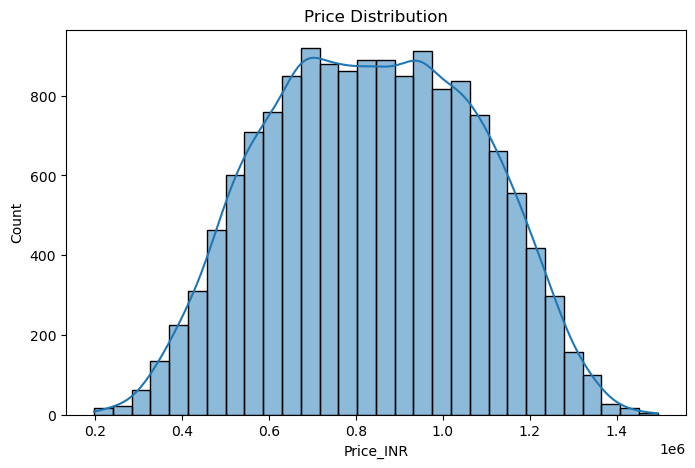

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['Price_INR'],bins=30,kde=True)

plt.title("Price Distribution")

plt.show()

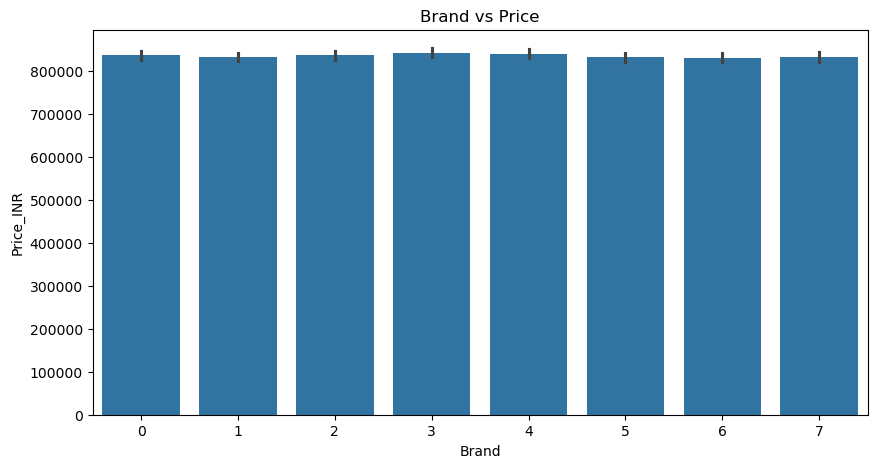

In [13]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Brand',
    y='Price_INR',
    data=df
)

plt.title("Brand vs Price")

plt.show()

In [14]:
lr = LinearRegression()

lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression")

print("R2 Score =",r2_score(y_test,y_pred_lr))

print("MAE =",mean_absolute_error(y_test,y_pred_lr))

print("RMSE =",np.sqrt(mean_squared_error(y_test,y_pred_lr)))

Linear Regression
R2 Score = 0.9426520499091727
MAE = 49334.38311709034
RMSE = 57109.94941707787


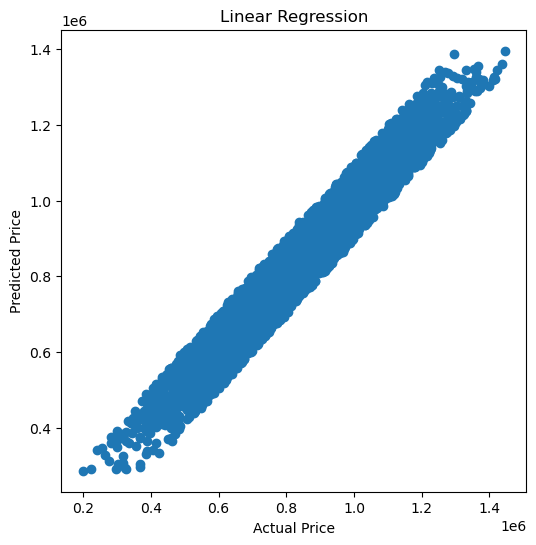

In [15]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,y_pred_lr)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Linear Regression")

plt.show()

In [16]:
knn = KNeighborsRegressor(
    n_neighbors=5
)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("------ KNN Regression ------")

print("R2 Score :", r2_score(y_test, y_pred_knn))
print("MAE :", mean_absolute_error(y_test, y_pred_knn))
print("MSE :", mean_squared_error(y_test, y_pred_knn))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_knn)))

------ KNN Regression ------
R2 Score : 0.8256671125745538
MAE : 79621.5362
MSE : 9914823231.850412
RMSE : 99573.20539106097


In [17]:
svr = SVR(kernel='rbf')

svr.fit(X_train_scaled,y_train)

y_pred_svr = svr.predict(X_test_scaled)

print("SVR")

print("R2 Score =",r2_score(y_test,y_pred_svr))

print("MAE =",mean_absolute_error(y_test,y_pred_svr))

print("RMSE =",np.sqrt(mean_squared_error(y_test,y_pred_svr)))

SVR
R2 Score = 0.0005236172057645483
MAE = 199901.4922851956
RMSE = 238418.02957362705


In [18]:
dt = DecisionTreeRegressor(
    max_depth=8,
    random_state=42
)

dt.fit(X_train,y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree")

print("R2 Score =",r2_score(y_test,y_pred_dt))

print("MAE =",mean_absolute_error(y_test,y_pred_dt))

print("RMSE =",np.sqrt(mean_squared_error(y_test,y_pred_dt)))

Decision Tree
R2 Score = 0.9282720042214745
MAE = 53411.16052391857
RMSE = 63870.03794666739


In [19]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")

print("R2 Score =",r2_score(y_test,y_pred_rf))

print("MAE =",mean_absolute_error(y_test,y_pred_rf))

print("RMSE =",np.sqrt(mean_squared_error(y_test,y_pred_rf)))

Random Forest
R2 Score = 0.9365137620725577
MAE = 50880.1045317361
RMSE = 60088.674279028775


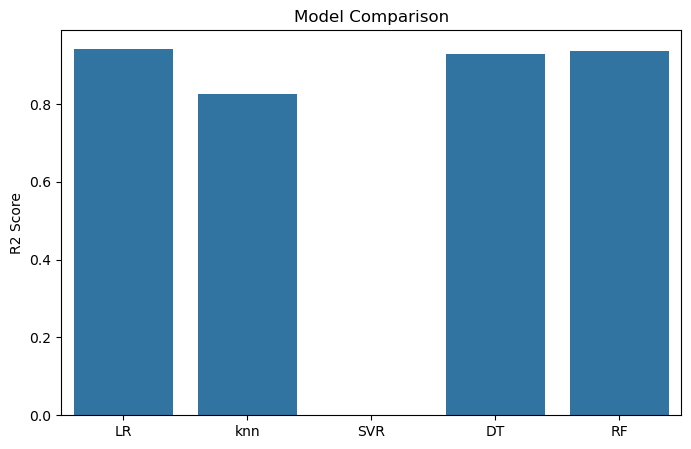

In [20]:
models = ['LR','knn','SVR','DT','RF']

scores = [
    r2_score(y_test,y_pred_lr),
     r2_score(y_test,y_pred_knn),
    r2_score(y_test,y_pred_svr),
    r2_score(y_test,y_pred_dt),
    r2_score(y_test,y_pred_rf)
]

plt.figure(figsize=(8,5))

sns.barplot(
    x=models,
    y=scores
)

plt.title("Model Comparison")

plt.ylabel("R2 Score")

plt.show()

In [21]:
sample = pd.DataFrame([[
    5,      # Brand
    10,     # Model
    3,      # Year
    1,      # Fuel Type
    0,      # Transmission
    0,      # Owner
    45000,  # KM Driven
    1197,   # Engine
    22.5,   # Mileage
    5,      # Seats
    2,      # Location
    1       # Insurance
]],columns=X.columns)

In [22]:
price = rf.predict(sample)

print("Predicted Car Price = ₹",round(price[0],2))

Predicted Car Price = ₹ 599367.46
